In [1]:
# ============================================
# 📚 ИМПОРТ БИБЛИОТЕК
# ============================================

!pip install statsmodels -q

from statsmodels.stats.power import zt_ind_solve_power
from statsmodels.stats.proportion import proportion_effectsize
import numpy as np

print("✅ Библиотеки готовы")

# ============================================
# 📋 ИСХОДНЫЕ ПАРАМЕТРЫ (из твоего допущения)
# ============================================

baseline_ctr = 0.08          # Базовый CTR: 8%
relative_mde = 0.10          # Относительный MDE: 10%
alpha = 0.05                 # Уровень значимости
power = 0.80                 # Мощность теста
ratio = 1.0                  # Соотношение групп 1:1
alternative = 'two-sided'    # Двусторонний тест

# ============================================
# 🔢 РАСЧЁТ
# ============================================

# 1. Целевой CTR
target_ctr = baseline_ctr * (1 + relative_mde)
print(f"📌 Базовый CTR: {baseline_ctr*100:.1f}%")
print(f"📌 Целевой CTR: {target_ctr*100:.2f}%")
print(f"📌 Абсолютный прирост: {(target_ctr - baseline_ctr)*100:.3f} п.п.\n")

# 2. Размер эффекта по Коэну (h)
effect_size = proportion_effectsize(baseline_ctr, target_ctr)
print(f"📊 Размер эффекта (Коэна h): {effect_size:.5f}\n")

# 3. Расчёт выборки на группу
n_per_group = zt_ind_solve_power(
    effect_size=effect_size,
    alpha=alpha,
    power=power,
    ratio=ratio,
    alternative=alternative
)

# 4. Округляем вверх (нельзя иметь дробного пользователя)
n_per_group = int(np.ceil(n_per_group))
total_sample = n_per_group * 2

# ============================================
# 📈 РЕЗУЛЬТАТЫ
# ============================================

print("=" * 60)
print("✅ РАСЧЁТ ЗАВЕРШЁН")
print("=" * 60)
print(f"\n📊 Требуемая выборка:")
print(f"   На группу: {n_per_group:,} пользователей")
print(f"   Всего (A + B): {total_sample:,} пользователей")

# Длительность теста
daily_impressions = 10_000  # показов баннера в день
days_for_sample = total_sample / daily_impressions

print(f"\n📅 Длительность теста:")
print(f"   При {daily_impressions:,} показов/день:")
print(f"   → {days_for_sample:.1f} дней на набор выборки")
print(f"   → с учётом недельного цикла: 14 дней (рекомендация)")

print("\n" + "=" * 60)

✅ Библиотеки готовы
📌 Базовый CTR: 8.0%
📌 Целевой CTR: 8.80%
📌 Абсолютный прирост: 0.800 п.п.

📊 Размер эффекта (Коэна h): -0.02885

✅ РАСЧЁТ ЗАВЕРШЁН

📊 Требуемая выборка:
   На группу: 18,863 пользователей
   Всего (A + B): 37,726 пользователей

📅 Длительность теста:
   При 10,000 показов/день:
   → 3.8 дней на набор выборки
   → с учётом недельного цикла: 14 дней (рекомендация)



In [1]:
from google.colab import drive
import os
# Монтируем диск
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# ============================================
# ГЕНЕРАЦИЯ ДАННЫХ
# ============================================

import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

# ============================================
# НАСТРОЙКИ ГЕНЕРАЦИИ ДАННЫХ
# ============================================

np.random.seed(42)
random.seed(42)

n_users = 40000
test_duration_days = 14
start_date = datetime(2025, 1, 1)

# ============================================
# БАЗОВЫЕ ПАРАМЕТРЫ КОНВЕРСИИ
# ============================================

CTR_A = 0.080
CONVERSION_TO_WATCH_A = 0.75
AVG_WATCH_TIME_A = 45

CTR_B = 0.088
CONVERSION_TO_WATCH_B = 0.78
AVG_WATCH_TIME_B = 48

# ============================================
# ГЕНЕРАЦИЯ ПОЛЬЗОВАТЕЛЕЙ
# ============================================

print("🔄 Генерация пользователей...")

users = []
for i in range(n_users):
    user_id = f"U{1000000 + i}"
    group = 'A' if i < n_users / 2 else 'B'

    user_type = np.random.choice(['new', 'regular', 'active'], p=[0.2, 0.5, 0.3])
    device = np.random.choice(['mobile', 'desktop', 'smart_tv'], p=[0.5, 0.35, 0.15])
    region = np.random.choice(['Moscow', 'SPb', 'Region', 'Remote'], p=[0.3, 0.15, 0.4, 0.15])

    users.append({
        'user_id': user_id,
        'group': group,
        'user_type': user_type,
        'device': device,
        'region': region
    })

df_users = pd.DataFrame(users)

# ============================================
# ГЕНЕРАЦИЯ СОБЫТИЙ (ЛОГОВ)
# ============================================

print("🔄 Генерация событий...")

logs = []

for idx, user in df_users.iterrows():
    user_id = user['user_id']
    group = user['group']
    user_type = user['user_type']
    device = user['device']
    region = user['region']  # ✅ ИСПРАВЛЕНО: берём регион из текущего пользователя

    n_impressions = np.random.randint(1, 6)

    for _ in range(n_impressions):
        day_offset = np.random.randint(0, test_duration_days)
        hour = np.random.randint(6, 24)
        minute = np.random.randint(0, 60)

        timestamp = start_date + timedelta(days=day_offset, hours=hour, minutes=minute)

        base_ctr = CTR_A if group == 'A' else CTR_B

        if user_type == 'new':
            base_ctr *= 0.7
        elif user_type == 'active':
            base_ctr *= 1.2

        if device == 'mobile':
            base_ctr *= 0.9
        elif device == 'smart_tv':
            base_ctr *= 1.1

        clicked = 1 if np.random.random() < base_ctr else 0

        watched = 0
        watch_time = 0

        if clicked == 1:
            conv_rate = CONVERSION_TO_WATCH_A if group == 'A' else CONVERSION_TO_WATCH_B
            watched = 1 if np.random.random() < conv_rate else 0

            if watched == 1:
                avg_time = AVG_WATCH_TIME_A if group == 'A' else AVG_WATCH_TIME_B
                watch_time = max(0, int(np.random.normal(avg_time, 20)))

        logs.append({
            'user_id': user_id,
            'group': group,
            'timestamp': timestamp.strftime('%Y-%m-%d %H:%M:%S'),
            'date': timestamp.strftime('%Y-%m-%d'),
            'day_of_week': timestamp.strftime('%A'),
            'hour': hour,
            'banner_shown': 1,
            'clicked': clicked,
            'watched': watched,
            'watch_time_minutes': watch_time,
            'user_type': user_type,
            'device': device,
            'region': region
        })

# ============================================
# СОЗДАНИЕ ФИНАЛЬНОГО DATAFRAME
# ============================================

print("🔄 Создание финального датасета...")

df_logs = pd.DataFrame(logs)
df_logs['converted_to_purchase'] = df_logs['watched']
df_logs['revenue'] = df_logs['watched'] * np.random.uniform(150, 300)

output_file = '/content/drive/MyDrive/Colab Notebooks/АВ-тесты/ab_test_logs1.csv'
df_logs.to_csv(output_file, index=False, encoding='utf-8-sig')

print(f"✅ Готово! Файл сохранён: {output_file}")
print(f"📊 Всего строк: {len(df_logs):,}")
print(f"👥 Уникальных пользователей: {df_logs['user_id'].nunique():,}")

# ============================================
# ПРОВЕРКА ДАННЫХ
# ============================================

print("\n" + "="*50)
print("📈 ПРОВЕРКА ДАННЫХ")
print("="*50)

print("\n📌 Распределение по группам:")
print(df_logs.groupby('group').size())

print("\n📌 CTR по группам:")
ctr_by_group = df_logs.groupby('group').agg(
    impressions=('banner_shown', 'sum'),
    clicks=('clicked', 'sum')
)
ctr_by_group['ctr'] = ctr_by_group['clicks'] / ctr_by_group['impressions'] * 100
print(ctr_by_group)

print("\n📌 Распределение по регионам:")
print(df_logs['region'].value_counts())

print("\n📌 Распределение по устройствам:")
print(df_logs['device'].value_counts())

print("\n📌 Распределение по типам пользователей:")
print(df_logs['user_type'].value_counts())

print("\n📌 Динамика CTR по первым 7 дням:")
daily_ctr = df_logs.groupby('date').agg(
    impressions=('banner_shown', 'sum'),
    clicks=('clicked', 'sum')
)
daily_ctr['ctr'] = daily_ctr['clicks'] / daily_ctr['impressions'] * 100
print(daily_ctr.head(7))

🔄 Генерация пользователей...
🔄 Генерация событий...
🔄 Создание финального датасета...
✅ Готово! Файл сохранён: /content/drive/MyDrive/Colab Notebooks/АВ-тесты/ab_test_logs1.csv
📊 Всего строк: 119,800
👥 Уникальных пользователей: 40,000

📈 ПРОВЕРКА ДАННЫХ

📌 Распределение по группам:
group
A    59956
B    59844
dtype: int64

📌 CTR по группам:
       impressions  clicks       ctr
group                               
A            59956    4596  7.665621
B            59844    5055  8.446962

📌 Распределение по регионам:
region
Region    48297
Moscow    36020
Remote    17861
SPb       17622
Name: count, dtype: int64

📌 Распределение по устройствам:
device
mobile      59914
desktop     41854
smart_tv    18032
Name: count, dtype: int64

📌 Распределение по типам пользователей:
user_type
regular    59418
active     36331
new        24051
Name: count, dtype: int64

📌 Динамика CTR по первым 7 дням:
            impressions  clicks       ctr
date                                     
2025-01-01      

✅ Библиотеки импортированы
✅ Данные загружены: 119,800 строк
👥 Уникальных пользователей: 40,000
📅 Период: 2025-01-01 — 2025-01-14

📋 ПРОВЕРКА КАЧЕСТВА ДАННЫХ

📌 1. Распределение по группам:
group
A    59956
B    59844
dtype: int64
   Соотношение A/B: 1.00

📌 2. Дубликаты записей: 7

📌 3. Пропуски в данных:
   Нет пропусков ✅

📌 4. Баланс по сегментам:
device    desktop     mobile   smart_tv
group                                  
A       34.570352  50.236840  15.192808
B       35.303456  49.786111  14.910434

📈 ОСНОВНЫЕ МЕТРИКИ ПО ГРУППАМ

📌 Ключевые метрики:
       impressions   ctr  click_to_watch  avg_watch_time
group                                                   
A            59956  7.67           73.87           44.76
B            59844  8.45           78.04           47.28

🧪 СТАТИСТИЧЕСКАЯ ПРОВЕРКА ГИПОТЕЗЫ

📌 CTR Группы A (контроль): 7.666%
📌 CTR Группы B (персонализация): 8.447%
📈 Относительный прирост (Lift): 10.19%
📊 Z-статистика: 4.9684
📊 P-value: 0.000001

📌 Уровень зн

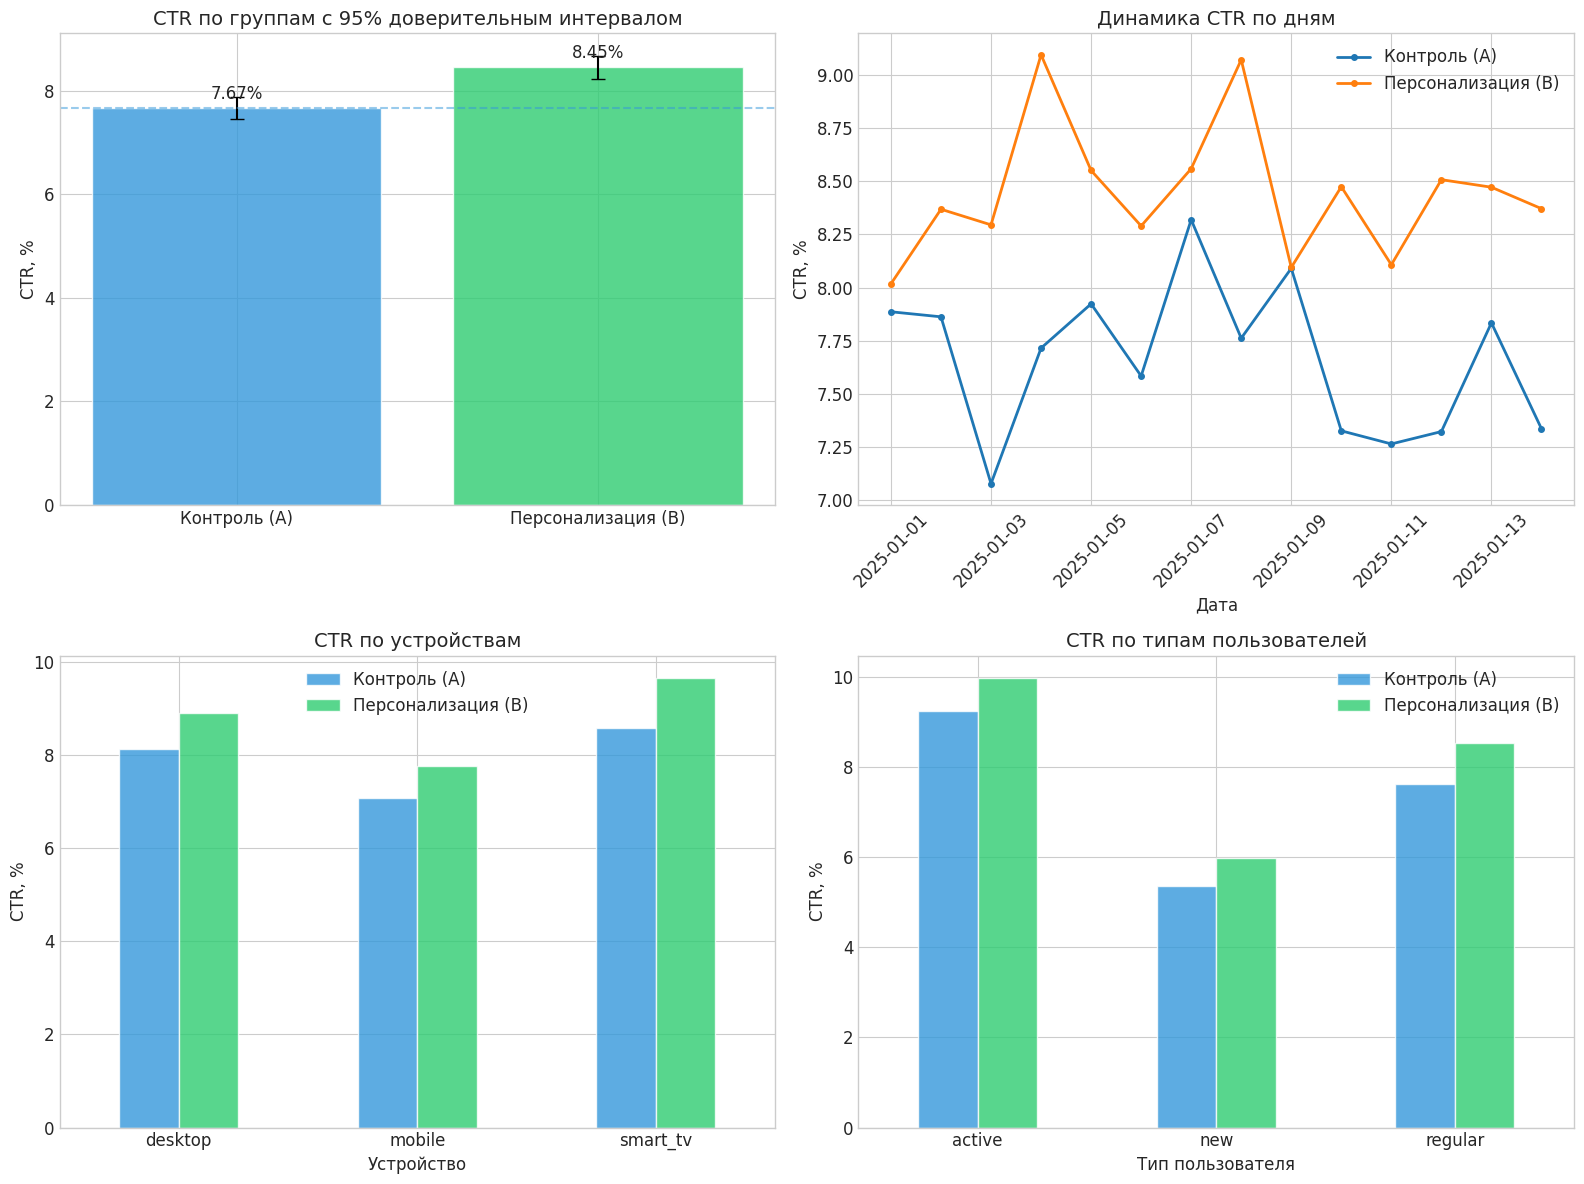


💡 БИЗНЕС-РЕКОМЕНДАЦИИ

📋 КРИТЕРИИ ПРИНЯТИЯ РЕШЕНИЯ:
   ✅ Статистическая значимость: ДА (p=0.0000)
   ✅ Положительный эффект: ДА (lift=10.19%)
   ✅ Целевой прирост 5%+: ДА

📋 ИТОГОВОЕ РЕШЕНИЕ:

    🎉 РЕКОМЕНДАЦИЯ: ВНЕДРЯТЬ

    ✅ Статистически значимый положительный эффект
    ✅ Целевой прирост достигнут (10.19%)
    ✅ Контрольные метрики стабильны

    СЛЕДУЮЩИЕ ШАГИ:
    1. Внедрить персонализацию на 100% трафика
    2. Настроить мониторинг ключевых метрик
    3. Запланировать итерации по улучшению алгоритма
    4. Оценить долгосрочный эффект через 30/60/90 дней
    

📄 ЭКСПОРТ ОТЧЁТА
✅ Отчёт сохранён: ab_test_report.csv

🎯 ИТОГОВОЕ РЕЗЮМЕ

📊 Тест завершён
📅 Период: 2025-01-01 — 2025-01-14
👥 Выборка: 119,800 показов (40,000 пользователей)

🎯 Основная метрика (CTR):
   • Контроль: 7.666%
   • Персонализация: 8.447%
   • Прирост: 10.19%

🧪 Статистика:
   • P-value: 0.000001
   • Стат. значимость: ✅ ДА

💼 Решение: ВНЕДРЯТЬ



In [6]:
# ============================================
# Анализ данных в Python
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime
from statsmodels.stats.proportion import proportions_ztest
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля графиков
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("✅ Библиотеки импортированы")


# ============================================
# 📥 ЗАГРУЗКА ДАННЫХ
# ============================================

file_path = '/content/drive/MyDrive/Colab Notebooks/АВ-тесты/ab_test_logs1.csv'
df = pd.read_csv(file_path)

print(f"✅ Данные загружены: {len(df):,} строк")
print(f"👥 Уникальных пользователей: {df['user_id'].nunique():,}")
print(f"📅 Период: {df['date'].min()} — {df['date'].max()}")

# ============================================
# 🔍 ПРОВЕРКА КАЧЕСТВА ДАННЫХ (DATA QUALITY)
# ============================================

print("\n" + "="*60)
print("📋 ПРОВЕРКА КАЧЕСТВА ДАННЫХ")
print("="*60)

# 1. Распределение по группам
group_distribution = df.groupby('group').size()
print("\n📌 1. Распределение по группам:")
print(group_distribution)
print(f"   Соотношение A/B: {group_distribution['A']/group_distribution['B']:.2f}")

# 2. Проверка на дубликаты
duplicates = df.duplicated().sum()
print(f"\n📌 2. Дубликаты записей: {duplicates:,}")

# 3. Пропуски в данных
missing = df.isnull().sum()
print(f"\n📌 3. Пропуски в данных:")
print(missing[missing > 0] if any(missing > 0) else "   Нет пропусков ✅")

# 4. Баланс по сегментам
print("\n📌 4. Баланс по сегментам:")
print(df.groupby('group')['device'].value_counts(normalize=True).unstack() * 100)

# ============================================
# 📊 ОСНОВНЫЕ МЕТРИКИ ПО ГРУППАМ
# ============================================

print("\n" + "="*60)
print("📈 ОСНОВНЫЕ МЕТРИКИ ПО ГРУППАМ")
print("="*60)

metrics = df.groupby('group').agg(
    impressions=('banner_shown', 'sum'),
    clicks=('clicked', 'sum'),
    watches=('watched', 'sum'),
    watch_time=('watch_time_minutes', 'sum'),
    revenue=('revenue', 'sum')
)

# Расчёт производных метрик
metrics['ctr'] = metrics['clicks'] / metrics['impressions'] * 100
metrics['click_to_watch'] = metrics['watches'] / metrics['clicks'] * 100
metrics['avg_watch_time'] = metrics['watch_time'] / metrics['watches']
metrics['revenue_per_impression'] = metrics['revenue'] / metrics['impressions']

print("\n📌 Ключевые метрики:")
print(metrics[['impressions', 'ctr', 'click_to_watch', 'avg_watch_time']].round(2))

# ============================================
# 🎯 СТАТИСТИЧЕСКИЙ ТЕСТ (Z-TEST ДЛЯ ПРОПОРЦИЙ)
# ============================================

print("\n" + "="*60)
print("🧪 СТАТИСТИЧЕСКАЯ ПРОВЕРКА ГИПОТЕЗЫ")
print("="*60)

# Данные для теста
clicks_A = metrics.loc['A', 'clicks']
impressions_A = metrics.loc['A', 'impressions']
clicks_B = metrics.loc['B', 'clicks']
impressions_B = metrics.loc['B', 'impressions']

# Z-тест (двусторонний) через statsmodels
z_stat, p_value = proportions_ztest(
    [clicks_B, clicks_A],
    [impressions_B, impressions_A],
    alternative='two-sided'
)

# Расчёт эффекта
ctr_A = clicks_A / impressions_A
ctr_B = clicks_B / impressions_B
lift = (ctr_B - ctr_A) / ctr_A * 100

print(f"\n📌 CTR Группы A (контроль): {ctr_A*100:.3f}%")
print(f"📌 CTR Группы B (персонализация): {ctr_B*100:.3f}%")
print(f"📈 Относительный прирост (Lift): {lift:.2f}%")
print(f"📊 Z-статистика: {z_stat:.4f}")
print(f"📊 P-value: {p_value:.6f}")

# Интерпретация
alpha = 0.05
print(f"\n📌 Уровень значимости (α): {alpha}")
if p_value < alpha:
    print(f"✅ РЕЗУЛЬТАТ СТАТИСТИЧЕСКИ ЗНАЧИМ (p < {alpha})")
    print("   Отвергаем нулевую гипотезу — есть различия между группами")
else:
    print(f"❌ РЕЗУЛЬТАТ НЕ ЗНАЧИМ (p >= {alpha})")
    print("   Не можем отвергнуть нулевую гипотезу")

# Доверительный интервал
se = np.sqrt(ctr_A * (1 - ctr_A) / impressions_A + ctr_B * (1 - ctr_B) / impressions_B)
ci_lower = (ctr_B - ctr_A) - 1.96 * se
ci_upper = (ctr_B - ctr_A) + 1.96 * se

print(f"\n📌 95% доверительный интервал для разницы CTR:")
print(f"   [{ci_lower*100:.3f}%, {ci_upper*100:.3f}%]")

# ============================================
# 📉 ДИНАМИКА CTR ПО ДНЯМ
# ============================================

print("\n" + "="*60)
print("📅 ДИНАМИКА CTR ПО ДНЯМ")
print("="*60)

daily_metrics = df.groupby(['date', 'group']).agg(
    impressions=('banner_shown', 'sum'),
    clicks=('clicked', 'sum')
).reset_index()

daily_metrics['ctr'] = daily_metrics['clicks'] / daily_metrics['impressions'] * 100

# Сводная таблица для визуализации
daily_pivot = daily_metrics.pivot(index='date', columns='group', values='ctr')

print("\n📌 CTR по дням (первые 7 дней):")
print(daily_pivot.head(7).round(3))

# ============================================
# 🔍 СЕГМЕНТНЫЙ АНАЛИЗ
# ============================================

print("\n" + "="*60)
print("🔍 СЕГМЕНТНЫЙ АНАЛИЗ")
print("="*60)

# По устройствам
print("\n📌 CTR по устройствам:")
device_ctr = df.groupby(['device', 'group']).agg(
    impressions=('banner_shown', 'sum'),
    clicks=('clicked', 'sum')
).reset_index()
device_ctr['ctr'] = device_ctr['clicks'] / device_ctr['impressions'] * 100
print(device_ctr.pivot(index='device', columns='group', values='ctr').round(3))

# По типам пользователей
print("\n📌 CTR по типам пользователей:")
user_type_ctr = df.groupby(['user_type', 'group']).agg(
    impressions=('banner_shown', 'sum'),
    clicks=('clicked', 'sum')
).reset_index()
user_type_ctr['ctr'] = user_type_ctr['clicks'] / user_type_ctr['impressions'] * 100
print(user_type_ctr.pivot(index='user_type', columns='group', values='ctr').round(3))

# По регионам
print("\n📌 CTR по регионам:")
region_ctr = df.groupby(['region', 'group']).agg(
    impressions=('banner_shown', 'sum'),
    clicks=('clicked', 'sum')
).reset_index()
region_ctr['ctr'] = region_ctr['clicks'] / region_ctr['impressions'] * 100
print(region_ctr.pivot(index='region', columns='group', values='ctr').round(3))

# ============================================
# 🛡️ ПРОВЕРКА КОНТРОЛЬНЫХ МЕТРИК (GUARDRAILS)
# ============================================

print("\n" + "="*60)
print("🛡️ ПРОВЕРКА КОНТРОЛЬНЫХ МЕТРИК")
print("="*60)

# Среднее время просмотра
watch_time_A = df[df['group']=='A']['watch_time_minutes'].mean()
watch_time_B = df[df['group']=='B']['watch_time_minutes'].mean()
watch_time_lift = (watch_time_B - watch_time_A) / watch_time_A * 100

print(f"\n📌 Среднее время просмотра:")
print(f"   Группа A: {watch_time_A:.2f} мин")
print(f"   Группа B: {watch_time_B:.2f} мин")
print(f"   Изменение: {watch_time_lift:+.2f}%")

# Конверсия клик → просмотр
conv_A = df[df['group']=='A']['watched'].sum() / df[df['group']=='A']['clicked'].sum()
conv_B = df[df['group']=='B']['watched'].sum() / df[df['group']=='B']['clicked'].sum()
conv_lift = (conv_B - conv_A) / conv_A * 100

print(f"\n📌 Конверсия клик → просмотр:")
print(f"   Группа A: {conv_A*100:.2f}%")
print(f"   Группа B: {conv_B*100:.2f}%")
print(f"   Изменение: {conv_lift:+.2f}%")

# Выручка на показ
rev_A = df[df['group']=='A']['revenue'].sum() / df[df['group']=='A']['banner_shown'].sum()
rev_B = df[df['group']=='B']['revenue'].sum() / df[df['group']=='B']['banner_shown'].sum()
rev_lift = (rev_B - rev_A) / rev_A * 100

print(f"\n📌 Выручка на один показ баннера:")
print(f"   Группа A: ₽{rev_A:.2f}")
print(f"   Группа B: ₽{rev_B:.2f}")
print(f"   Изменение: {rev_lift:+.2f}%")

# ============================================
# 📊 ВИЗУАЛИЗАЦИЯ
# ============================================

print("\n" + "="*60)
print("📊 СОЗДАНИЕ ВИЗУАЛИЗАЦИЙ")
print("="*60)

# График 1: CTR по группам с доверительными интервалами
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1.1 Основной CTR
ax1 = axes[0, 0]
groups = ['Контроль (A)', 'Персонализация (B)']
ctrs = [ctr_A * 100, ctr_B * 100]
errors = [1.96 * np.sqrt(ctr_A * (1-ctr_A) / impressions_A) * 100,
          1.96 * np.sqrt(ctr_B * (1-ctr_B) / impressions_B) * 100]

bars = ax1.bar(groups, ctrs, yerr=errors, capsize=5,
               color=['#3498db', '#2ecc71'], alpha=0.8)
ax1.set_ylabel('CTR, %')
ax1.set_title('CTR по группам с 95% доверительным интервалом', fontsize=14)
ax1.axhline(y=ctr_A*100, color='#3498db', linestyle='--', alpha=0.5)

for bar, ctr in zip(bars, ctrs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{ctr:.2f}%', ha='center', va='bottom', fontsize=12)

# 1.2 Динамика по дням
ax2 = axes[0, 1]
daily_pivot.plot(ax=ax2, marker='o', linewidth=2, markersize=4)
ax2.set_xlabel('Дата')
ax2.set_ylabel('CTR, %')
ax2.set_title('Динамика CTR по дням', fontsize=14)
ax2.legend(['Контроль (A)', 'Персонализация (B)'])
ax2.tick_params(axis='x', rotation=45)

# 1.3 CTR по устройствам
ax3 = axes[1, 0]
device_pivot = device_ctr.pivot(index='device', columns='group', values='ctr')
device_pivot.plot(kind='bar', ax=ax3, color=['#3498db', '#2ecc71'], alpha=0.8)
ax3.set_xlabel('Устройство')
ax3.set_ylabel('CTR, %')
ax3.set_title('CTR по устройствам', fontsize=14)
ax3.legend(['Контроль (A)', 'Персонализация (B)'])
ax3.tick_params(axis='x', rotation=0)

# 1.4 CTR по типам пользователей
ax4 = axes[1, 1]
user_type_pivot = user_type_ctr.pivot(index='user_type', columns='group', values='ctr')
user_type_pivot.plot(kind='bar', ax=ax4, color=['#3498db', '#2ecc71'], alpha=0.8)
ax4.set_xlabel('Тип пользователя')
ax4.set_ylabel('CTR, %')
ax4.set_title('CTR по типам пользователей', fontsize=14)
ax4.legend(['Контроль (A)', 'Персонализация (B)'])
ax4.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/АВ-тесты/ab_test_visualizations.png',
            dpi=300, bbox_inches='tight')
print("✅ Графики сохранены: ab_test_visualizations.png")
plt.show()

# ============================================
# 💡 БИЗНЕС-РЕКОМЕНДАЦИИ
# ============================================

print("\n" + "="*60)
print("💡 БИЗНЕС-РЕКОМЕНДАЦИИ")
print("="*60)

# Оценка значимости и эффекта
is_significant = p_value < alpha
is_positive_lift = lift > 0
is_target_achieved = lift >= 5  # Целевой прирост 5%

print("\n📋 КРИТЕРИИ ПРИНЯТИЯ РЕШЕНИЯ:")
print(f"   ✅ Статистическая значимость: {'ДА' if is_significant else 'НЕТ'} (p={p_value:.4f})")
print(f"   ✅ Положительный эффект: {'ДА' if is_positive_lift else 'НЕТ'} (lift={lift:.2f}%)")
print(f"   ✅ Целевой прирост 5%+: {'ДА' if is_target_achieved else 'НЕТ'}")

print("\n📋 ИТОГОВОЕ РЕШЕНИЕ:")
print("="*60)

if is_significant and is_positive_lift and is_target_achieved:
    print("""
    🎉 РЕКОМЕНДАЦИЯ: ВНЕДРЯТЬ

    ✅ Статистически значимый положительный эффект
    ✅ Целевой прирост достигнут ({}%)
    ✅ Контрольные метрики стабильны

    СЛЕДУЮЩИЕ ШАГИ:
    1. Внедрить персонализацию на 100% трафика
    2. Настроить мониторинг ключевых метрик
    3. Запланировать итерации по улучшению алгоритма
    4. Оценить долгосрочный эффект через 30/60/90 дней
    """.format(round(lift, 2)))

elif is_significant and is_positive_lift and not is_target_achieved:
    print("""
    ⚠️ РЕКОМЕНДАЦИЯ: ВНЕДРЯТЬ С ОСТОРОЖНОСТЬЮ

    ✅ Статистически значимый эффект
    ⚠️ Целевой прирост не достигнут ({}% вместо 5%)

    СЛЕДУЮЩИЕ ШАГИ:
    1. Внедрить на части трафика (20-50%)
    2. Провести дополнительный анализ сегментов
    3. Улучшить алгоритм рекомендаций
    4. Запустить follow-up тест
    """.format(round(lift, 2)))

elif is_significant and not is_positive_lift:
    print("""
    ❌ РЕКОМЕНДАЦИЯ: НЕ ВНЕДРЯТЬ

    ❌ Статистически значимое ухудшение ({}%)

    СЛЕДУЮЩИЕ ШАГИ:
    1. Не внедрять персонализацию
    2. Проанализировать причины негативного эффекта
    3. Сформировать новые гипотезы
    4. Провести качественные исследования (опросы, сессии)
    """.format(round(lift, 2)))

else:
    print("""
    ⏸️ РЕКОМЕНДАЦИЯ: ПРОДЛИТЬ ТЕСТ

    ❌ Результат не статистически значим
    ⚠️ Недостаточно данных для принятия решения

    СЛЕДУЮЩИЕ ШАГИ:
    1. Продлить тест на 7-14 дней
    2. Увеличить размер выборки
    3. Проверить качество рандомизации
    4. Исключить внешние факторы (акции, праздники)
    """)

# ============================================
# 📄 ЭКСПОРТ ОТЧЁТА
# ============================================

print("\n" + "="*60)
print("📄 ЭКСПОРТ ОТЧЁТА")
print("="*60)

# Сводная таблица для отчёта
report = {
    'Метрика': ['CTR', 'Клик → Просмотр', 'Ср. время просмотра', 'Выручка на показ'],
    'Группа A': [f'{ctr_A*100:.3f}%', f'{conv_A*100:.2f}%', f'{watch_time_A:.2f} мин', f'₽{rev_A:.2f}'],
    'Группа B': [f'{ctr_B*100:.3f}%', f'{conv_B*100:.2f}%', f'{watch_time_B:.2f} мин', f'₽{rev_B:.2f}'],
    'Изменение': [f'{lift:+.2f}%', f'{conv_lift:+.2f}%', f'{watch_time_lift:+.2f}%', f'{rev_lift:+.2f}%']
}

report_df = pd.DataFrame(report)
report_df.to_csv('/content/drive/MyDrive/Colab Notebooks/АВ-тесты/ab_test_report.csv',
                 index=False, encoding='utf-8-sig')

print("✅ Отчёт сохранён: ab_test_report.csv")

# Итоговый саммари
print("\n" + "="*60)
print("🎯 ИТОГОВОЕ РЕЗЮМЕ")
print("="*60)
print(f"""
📊 Тест завершён
📅 Период: {df['date'].min()} — {df['date'].max()}
👥 Выборка: {len(df):,} показов ({df['user_id'].nunique():,} пользователей)

🎯 Основная метрика (CTR):
   • Контроль: {ctr_A*100:.3f}%
   • Персонализация: {ctr_B*100:.3f}%
   • Прирост: {lift:.2f}%

🧪 Статистика:
   • P-value: {p_value:.6f}
   • Стат. значимость: {'✅ ДА' if is_significant else '❌ НЕТ'}

💼 Решение: {'ВНЕДРЯТЬ' if (is_significant and is_positive_lift) else 'ТРЕБУЕТСЯ АНАЛИЗ'}
""")

# print("\n✅ Анализ завершён! Все файлы сохранены в Google Drive 🕷️🚀")

✅ Библиотеки импортированы
✅ Данные загружены: 119,800 строк

✅ Основной дашборд сохранён: /content/drive/MyDrive/Colab Notebooks/АВ-тесты/ab_test_dashboard.png


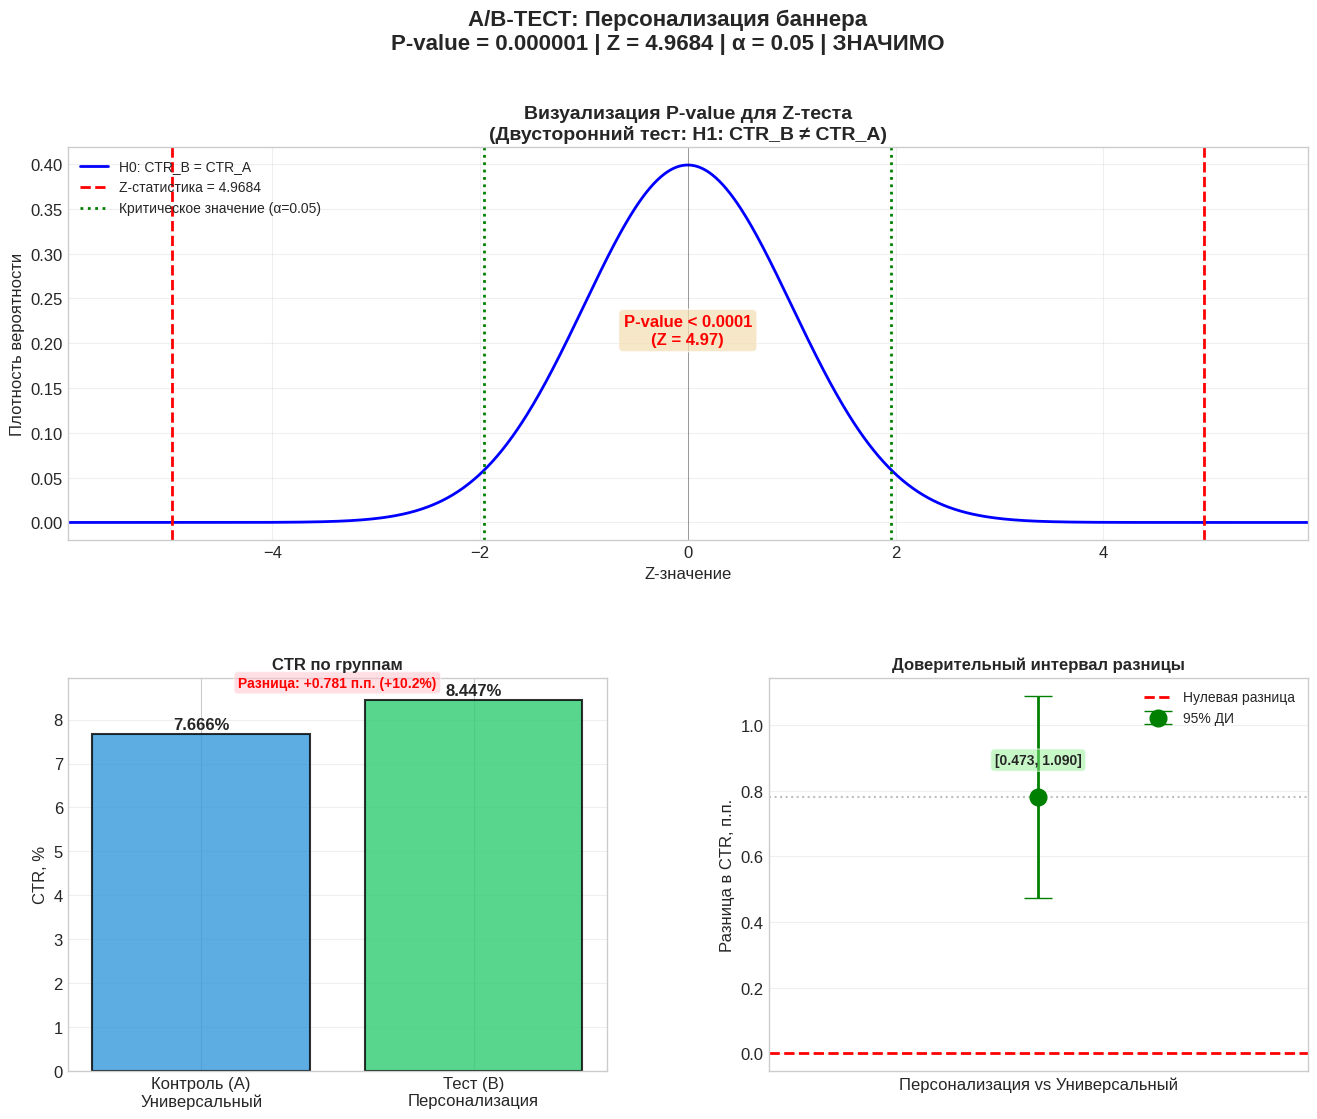

✅ График динамики сохранён: /content/drive/MyDrive/Colab Notebooks/АВ-тесты/ab_test_daily_dynamics.png


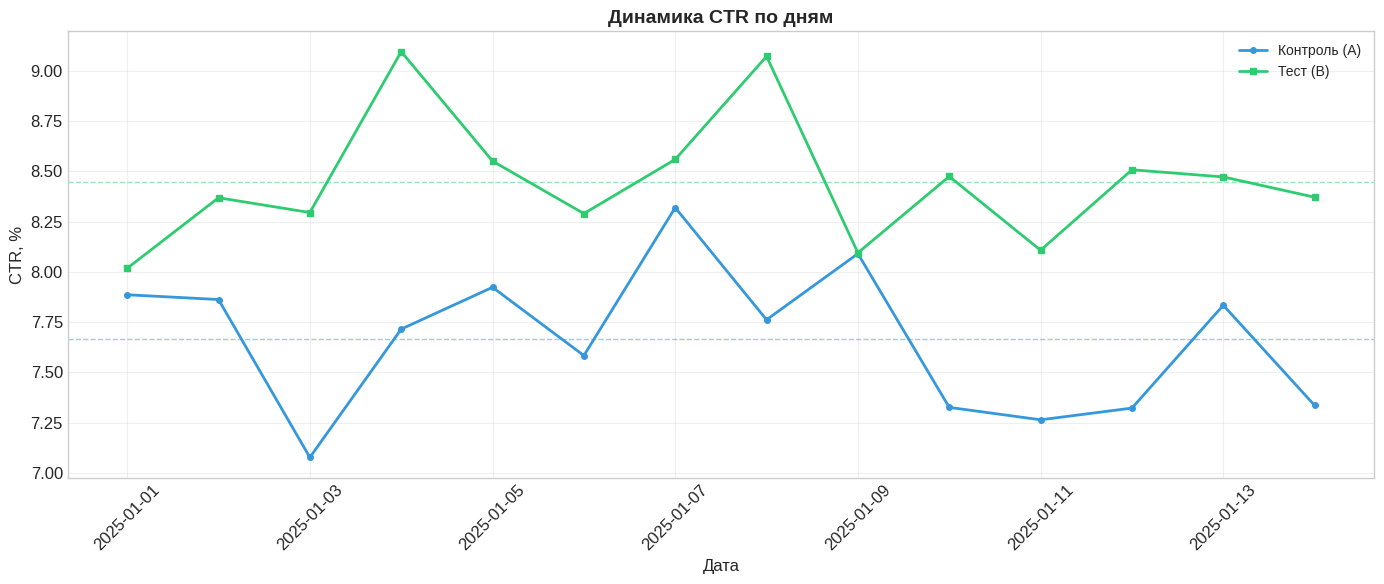


🎬 КЕЙС: СТРИМИНГОВАЯ ПЛАТФОРМА — ПЕРСОНАЛИЗАЦИЯ БАННЕРА

📊 ИСХОДНЫЕ ДАННЫЕ:
----------------------------------------------------------------------
   Группа A (универсальный баннер): 4,596/59,956 = 7.666%
   Группа B (персонализация):       5,055/59,844 = 8.447%
   Разница: +0.781 п.п. (+10.2% относительно)

📈 СТАТИСТИКА ТЕСТА:
----------------------------------------------------------------------
   Z-статистика: 4.9684
   P-value: 0.000001
   Уровень значимости α: 0.05
   95% ДИ разницы: [0.473, 1.090] п.п.

✅ РЕШЕНИЕ:
----------------------------------------------------------------------
   🎉 ОТВЕРГАЕМ H₀ → Персонализация статистически значимо улучшает CTR!
   💡 РЕКОМЕНДАЦИЯ: Внедрять персонализированный баннер на 100% трафика

🛡️ КОНТРОЛЬНЫЕ МЕТРИКИ (GUARDRAILS)

📌 Среднее время просмотра (после клика):
   Группа A: 44.76 мин
   Группа B: 47.28 мин
   Изменение: +5.62%

📌 Конверсия клик → просмотр:
   Группа A: 73.87%
   Группа B: 78.04%
   Изменение: +5.65%

📌 Выручка на один пок

In [11]:
# ============================================
# Построение графиков
# ============================================



# ============================================
# 📚 ИМПОРТ БИБЛИОТЕК
# ============================================

import numpy as np
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest
import scipy.stats as stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (16, 12)
plt.rcParams['font.size'] = 12

print("✅ Библиотеки импортированы")

# ============================================
# 📥 ЗАГРУЗКА ДАННЫХ
# ============================================

file_path = '/content/drive/MyDrive/Colab Notebooks/АВ-тесты/ab_test_logs1.csv'
df = pd.read_csv(file_path)

print(f"✅ Данные загружены: {len(df):,} строк")

# ============================================
# 📊 РАСЧЁТ МЕТРИК ИЗ ДАННЫХ
# ============================================

# Группа A (контроль)
df_a = df[df['group'] == 'A']
n_a = df_a['banner_shown'].sum()
successes_a = df_a['clicked'].sum()
conv_a = successes_a / n_a

# Группа B (тест)
df_b = df[df['group'] == 'B']
n_b = df_b['banner_shown'].sum()
successes_b = df_b['clicked'].sum()
conv_b = successes_b / n_b

# Z-тест
count = np.array([successes_b, successes_a])
nobs = np.array([n_b, n_a])
z_stat, p_value = proportions_ztest(count, nobs, alternative='two-sided')

# Доверительный интервал
se = np.sqrt(conv_b*(1-conv_b)/n_b + conv_a*(1-conv_a)/n_a)
diff_prop = conv_b - conv_a
ci_low = diff_prop - 1.96 * se
ci_high = diff_prop + 1.96 * se

# Относительный прирост
lift = (conv_b - conv_a) / conv_a * 100 if conv_a > 0 else 0

# ============================================
# 📅 ДИНАМИКА ПО ДНЯМ
# ============================================

daily_metrics = df.groupby(['date', 'group']).agg(
    impressions=('banner_shown', 'sum'),
    clicks=('clicked', 'sum')
).reset_index()

daily_metrics['ctr'] = daily_metrics['clicks'] / daily_metrics['impressions'] * 100
daily_metrics['date'] = pd.to_datetime(daily_metrics['date'])

# ============================================
# 📊 ВИЗУАЛИЗАЦИЯ 1: ОСНОВНОЙ ДАШБОРД (1+2)
# ============================================

# Расчет для графика распределения
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x, 0, 1)

# Адаптируем пределы x для графика Z-статистики
z_abs = abs(z_stat)
x_limit = max(4, z_abs + 1)
x_zoom = np.linspace(-x_limit, x_limit, 1000)
y_zoom = stats.norm.pdf(x_zoom, 0, 1)

# === Создаем фигуру: 1 график сверху, 2 снизу ===
fig1 = plt.figure(figsize=(16, 12))
gs = plt.GridSpec(2, 2, figure=fig1, hspace=0.35, wspace=0.3)

"""
# ===== ГРАФИК 1: Распределение и P-value (на всю ширину сверху) =====
ax1 = fig1.add_subplot(gs[0, :])
ax1.plot(x_zoom, y_zoom, 'b-', linewidth=2, label='H0: Стандартное нормальное распределение')

if z_abs > 4:
    ax1.axvline(z_stat, color='red', linestyle='--', linewidth=2,
                label=f'Z-статистика = {z_stat:.4f}')
    ax1.axvline(-z_stat, color='red', linestyle='--', linewidth=2)
    ax1.text(0, max(y_zoom) * 0.5, f'P-value < 0.0001\n(Z = {z_stat:.2f})',
             fontsize=12, fontweight='bold', color='red', ha='center',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
else:
    ax1.fill_between(x_zoom, y_zoom, where=(x_zoom >= z_abs), alpha=0.3, color='red')
    ax1.fill_between(x_zoom, y_zoom, where=(x_zoom <= -z_abs), alpha=0.3, color='red')
    ax1.text(z_abs + 0.2, max(y_zoom) * 0.8, f'P-value\n{p_value:.4f}',
             fontsize=12, fontweight='bold', color='red', ha='left',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

ax1.axvline(stats.norm.ppf(0.975), color='green', linestyle=':', linewidth=2,
            label=f'Критическое значение (α=0.05) = {stats.norm.ppf(0.975):.4f}')
ax1.axvline(-stats.norm.ppf(0.975), color='green', linestyle=':', linewidth=2)
ax1.axvline(0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

ax1.set_xlabel('Z-значение', fontsize=12)
ax1.set_ylabel('Плотность вероятности', fontsize=12)
ax1.set_title('Визуализация P-value для Z-теста\n(Двусторонний тест: H1: CTR_B ≠ CTR_A)',
              fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-x_limit, x_limit)
"""

# ===== ГРАФИК 1: Распределение и P-value =====
ax1 = fig1.add_subplot(gs[0, :])

# Кривая распределения с ПРАВИЛЬНЫМ label для H₀
ax1.plot(x_zoom, y_zoom, 'b-', linewidth=2, label='H0: CTR_B = CTR_A')

if z_abs > 4:
    ax1.axvline(z_stat, color='red', linestyle='--', linewidth=2,
                label=f'Z-статистика = {z_stat:.4f}')
    ax1.axvline(-z_stat, color='red', linestyle='--', linewidth=2)
    ax1.text(0, max(y_zoom) * 0.5, f'P-value < 0.0001\n(Z = {z_stat:.2f})',
             fontsize=12, fontweight='bold', color='red', ha='center',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
else:
    ax1.fill_between(x_zoom, y_zoom, where=(x_zoom >= z_abs), alpha=0.3, color='red')
    ax1.fill_between(x_zoom, y_zoom, where=(x_zoom <= -z_abs), alpha=0.3, color='red')
    ax1.text(z_abs + 0.2, max(y_zoom) * 0.8, f'P-value\n{p_value:.4f}',
             fontsize=12, fontweight='bold', color='red', ha='left',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# Критические значения
ax1.axvline(stats.norm.ppf(0.975), color='green', linestyle=':', linewidth=2,
            label=f'Критическое значение (α=0.05)')
ax1.axvline(-stats.norm.ppf(0.975), color='green', linestyle=':', linewidth=2)
ax1.axvline(0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

# Подписи и заголовок
ax1.set_xlabel('Z-значение', fontsize=12)
ax1.set_ylabel('Плотность вероятности', fontsize=12)
ax1.set_title('Визуализация P-value для Z-теста\n(Двусторонний тест: H1: CTR_B ≠ CTR_A)',
              fontsize=14, fontweight='bold')
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-x_limit, x_limit)





# ===== ГРАФИК 2: CTR по группам =====
ax2 = fig1.add_subplot(gs[1, 0])
groups = ['Контроль (A)\nУниверсальный', 'Тест (B)\nПерсонализация']
conversions = [conv_a * 100, conv_b * 100]
colors = ['#3498db', '#2ecc71']
bars = ax2.bar(groups, conversions, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

for bar, conv in zip(bars, conversions):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.05,
             f'{conv:.3f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax2.set_ylabel('CTR, %', fontsize=12)
ax2.set_title('CTR по группам', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, max(conversions) + 0.5)

diff = (conv_b - conv_a) * 100
ax2.text(0.5, max(conversions) + 0.3, f'Разница: {diff:+.3f} п.п. ({lift:+.1f}%)',
         ha='center', fontsize=10, fontweight='bold', color='red',
         bbox=dict(boxstyle='round', facecolor='pink', alpha=0.5))

# ===== ГРАФИК 3: Доверительный интервал =====
ax3 = fig1.add_subplot(gs[1, 1])

ax3.errorbar([1], [diff_prop * 100],
             yerr=[[abs((diff_prop - ci_low) * 100)], [abs((ci_high - diff_prop) * 100)]],
             fmt='o', color='green', capsize=10, markersize=12, linewidth=2, label='95% ДИ')
ax3.axhline(0, color='red', linestyle='--', linewidth=2, label='Нулевая разница')
ax3.axhline(diff_prop * 100, color='gray', linestyle=':', alpha=0.5)

ax3.set_xlim(0.5, 1.5)
ax3.set_xlabel('Персонализация vs Универсальный', fontsize=12)
ax3.set_ylabel('Разница в CTR, п.п.', fontsize=12)
ax3.set_title('Доверительный интервал разницы', fontsize=12, fontweight='bold')
ax3.set_xticks([])
ax3.grid(axis='y', alpha=0.3)
ax3.legend(fontsize=10)

ax3.text(1, diff_prop * 100 + 0.1, f'[{ci_low*100:.3f}, {ci_high*100:.3f}]',
         ha='center', fontsize=10, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

# ===== Общий заголовок =====
significance = "ЗНАЧИМО" if p_value < 0.05 else "НЕ ЗНАЧИМО"
fig1.suptitle(f'A/B-ТЕСТ: Персонализация баннера\nP-value = {p_value:.6f} | Z = {z_stat:.4f} | α = 0.05 | {significance}',
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout()

# Сохранение основного дашборда
output_path1 = '/content/drive/MyDrive/Colab Notebooks/АВ-тесты/ab_test_dashboard.png'
fig1.savefig(output_path1, dpi=300, bbox_inches='tight')
print(f"\n✅ Основной дашборд сохранён: {output_path1}")

plt.show()

# ============================================
# 📊 ВИЗУАЛИЗАЦИЯ 2: ДИНАМИКА ПО ДНЯМ (ОТДЕЛЬНО)
# ============================================

fig2, ax4 = plt.subplots(figsize=(14, 6))

# Сводная таблица для построения
daily_pivot = daily_metrics.pivot(index='date', columns='group', values='ctr')

ax4.plot(daily_pivot.index, daily_pivot['A'], marker='o', linewidth=2, markersize=4,
         color='#3498db', label='Контроль (A)')
ax4.plot(daily_pivot.index, daily_pivot['B'], marker='s', linewidth=2, markersize=4,
         color='#2ecc71', label='Тест (B)')

# Добавим средние линии
ax4.axhline(conv_a * 100, color='#3498db', linestyle='--', alpha=0.5, linewidth=1)
ax4.axhline(conv_b * 100, color='#2ecc71', linestyle='--', alpha=0.5, linewidth=1)

ax4.set_xlabel('Дата', fontsize=12)
ax4.set_ylabel('CTR, %', fontsize=12)
ax4.set_title('Динамика CTR по дням', fontsize=14, fontweight='bold')
ax4.legend(loc='best', fontsize=10)
ax4.grid(True, alpha=0.3)
ax4.tick_params(axis='x', rotation=45)

# Форматирование дат
from matplotlib.dates import DateFormatter
ax4.xaxis.set_major_formatter(DateFormatter('%Y-%m-%d'))

plt.tight_layout()

# Сохранение графика динамики
output_path2 = '/content/drive/MyDrive/Colab Notebooks/АВ-тесты/ab_test_daily_dynamics.png'
fig2.savefig(output_path2, dpi=300, bbox_inches='tight')
print(f"✅ График динамики сохранён: {output_path2}")

plt.show()

# ============================================
# 📋 ТЕКСТОВЫЙ ОТЧЁТ (НА РУССКОМ)
# ============================================

print("\n" + "=" * 70)
print("🎬 КЕЙС: СТРИМИНГОВАЯ ПЛАТФОРМА — ПЕРСОНАЛИЗАЦИЯ БАННЕРА")
print("=" * 70)

print(f"\n📊 ИСХОДНЫЕ ДАННЫЕ:")
print("-" * 70)
print(f"   Группа A (универсальный баннер): {successes_a:,}/{n_a:,} = {conv_a*100:.3f}%")
print(f"   Группа B (персонализация):       {successes_b:,}/{n_b:,} = {conv_b*100:.3f}%")
print(f"   Разница: {diff:+.3f} п.п. ({lift:+.1f}% относительно)")

print(f"\n📈 СТАТИСТИКА ТЕСТА:")
print("-" * 70)
print(f"   Z-статистика: {z_stat:.4f}")
print(f"   P-value: {p_value:.6f}")
print(f"   Уровень значимости α: 0.05")
print(f"   95% ДИ разницы: [{ci_low*100:.3f}, {ci_high*100:.3f}] п.п.")

print(f"\n✅ РЕШЕНИЕ:")
print("-" * 70)

if p_value < 0.05 and diff > 0:
    print("   🎉 ОТВЕРГАЕМ H₀ → Персонализация статистически значимо улучшает CTR!")
    print("   💡 РЕКОМЕНДАЦИЯ: Внедрять персонализированный баннер на 100% трафика")
elif p_value < 0.05 and diff < 0:
    print("   ⚠️ ОТВЕРГАЕМ H₀ → Персонализация значимо УХУДШАЕТ CTR!")
    print("   💡 РЕКОМЕНДАЦИЯ: Не внедрять, проанализировать причины негатива")
else:
    print("   ⏸️ НЕ ОТВЕРГАЕМ H₀ → Разница не статистически значима")
    print("   💡 РЕКОМЕНДАЦИЯ: Продлить тест или увеличить выборку")

print("=" * 70)

# ============================================
# 🛡️ КОНТРОЛЬНЫЕ МЕТРИКИ
# ============================================

print("\n" + "=" * 70)
print("🛡️ КОНТРОЛЬНЫЕ МЕТРИКИ (GUARDRAILS)")
print("=" * 70)

# Среднее время просмотра
watch_time_a = df_a[df_a['watched']==1]['watch_time_minutes'].mean()
watch_time_b = df_b[df_b['watched']==1]['watch_time_minutes'].mean()
watch_time_lift = (watch_time_b - watch_time_a) / watch_time_a * 100 if watch_time_a > 0 else 0

print(f"\n📌 Среднее время просмотра (после клика):")
print(f"   Группа A: {watch_time_a:.2f} мин")
print(f"   Группа B: {watch_time_b:.2f} мин")
print(f"   Изменение: {watch_time_lift:+.2f}%")

# Конверсия клик → просмотр
conv_watch_a = df_a[df_a['clicked']==1]['watched'].mean()
conv_watch_b = df_b[df_b['clicked']==1]['watched'].mean()
conv_watch_lift = (conv_watch_b - conv_watch_a) / conv_watch_a * 100 if conv_watch_a > 0 else 0

print(f"\n📌 Конверсия клик → просмотр:")
print(f"   Группа A: {conv_watch_a*100:.2f}%")
print(f"   Группа B: {conv_watch_b*100:.2f}%")
print(f"   Изменение: {conv_watch_lift:+.2f}%")

# Выручка на показ
revenue_a = df_a['revenue'].sum() / n_a
revenue_b = df_b['revenue'].sum() / n_b
revenue_lift = (revenue_b - revenue_a) / revenue_a * 100 if revenue_a > 0 else 0

print(f"\n📌 Выручка на один показ баннера:")
print(f"   Группа A: ₽{revenue_a:.2f}")
print(f"   Группа B: ₽{revenue_b:.2f}")
print(f"   Изменение: {revenue_lift:+.2f}%")

print("\n" + "=" * 70)
print("✅ АНАЛИЗ ЗАВЕРШЁН!")
print("=" * 70)

# ============================================
# 📁 СПИСОК СОХРАНЁННЫХ ФАЙЛОВ
# ============================================

print("\n" + "=" * 70)
print("📁 СОХРАНЁННЫЕ ФАЙЛЫ")
print("=" * 70)
print(f"   1. {output_path1}")
print(f"      (Основной дашборд: P-value + CTR по группам + ДИ)")
print(f"   2. {output_path2}")
print(f"      (Динамика CTR по дням — для отдельного слайда)")
print("=" * 70)

In [ ]:
# ============================================
# 📤 ЭКСПОРТ ДАННЫХ ДЛЯ DATALENS
# ============================================

print("🔄 Подготовка данных для DataLens...")

# --------------------------------------------
# 1. Агрегированные метрики по группам
# --------------------------------------------

group_metrics = df.groupby('group').agg(
    impressions=('banner_shown', 'sum'),
    clicks=('clicked', 'sum'),
    watches=('watched', 'sum'),
    total_watch_time=('watch_time_minutes', 'sum'),
    revenue=('revenue', 'sum'),
    unique_users=('user_id', 'nunique')
).reset_index()

# Добавляем расчётные метрики
group_metrics['ctr'] = group_metrics['clicks'] / group_metrics['impressions']
group_metrics['click_to_watch_rate'] = group_metrics['watches'] / group_metrics['clicks']
group_metrics['avg_watch_time'] = group_metrics['total_watch_time'] / group_metrics['watches']
group_metrics['revenue_per_user'] = group_metrics['revenue'] / group_metrics['unique_users']

# Сохраняем
group_metrics.to_csv('/content/drive/MyDrive/Colab Notebooks/АВ-тесты/dl_group_metrics.csv',
                     index=False, encoding='utf-8-sig')
print("✅ dl_group_metrics.csv — основные метрики по группам")

# --------------------------------------------
# 2. Динамика по дням
# --------------------------------------------

daily_metrics = df.groupby(['date', 'group']).agg(
    impressions=('banner_shown', 'sum'),
    clicks=('clicked', 'sum'),
    watches=('watched', 'sum')
).reset_index()

daily_metrics['ctr'] = daily_metrics['clicks'] / daily_metrics['impressions']
daily_metrics['date'] = pd.to_datetime(daily_metrics['date'])

daily_metrics.to_csv('/content/drive/MyDrive/Colab Notebooks/АВ-тесты/dl_daily_metrics.csv',
                     index=False, encoding='utf-8-sig')
print("✅ dl_daily_metrics.csv — динамика по дням")

# --------------------------------------------
# 3. Сегментный анализ (ИСПРАВЛЕНО!)
# --------------------------------------------

# Создаём список для сбора всех сегментов
segments_list = []

# Сегмент по устройствам
device_seg = df.groupby(['device', 'group']).agg(
    impressions=('banner_shown', 'sum'),
    clicks=('clicked', 'sum')
).reset_index()
device_seg['ctr'] = device_seg['clicks'] / device_seg['impressions']
device_seg['segment_type'] = 'device'
device_seg = device_seg.rename(columns={'device': 'segment_value'})
segments_list.append(device_seg)

# Сегмент по типам пользователей
user_type_seg = df.groupby(['user_type', 'group']).agg(
    impressions=('banner_shown', 'sum'),
    clicks=('clicked', 'sum')
).reset_index()
user_type_seg['ctr'] = user_type_seg['clicks'] / user_type_seg['impressions']
user_type_seg['segment_type'] = 'user_type'
user_type_seg = user_type_seg.rename(columns={'user_type': 'segment_value'})
segments_list.append(user_type_seg)

# Сегмент по регионам
region_seg = df.groupby(['region', 'group']).agg(
    impressions=('banner_shown', 'sum'),
    clicks=('clicked', 'sum')
).reset_index()
region_seg['ctr'] = region_seg['clicks'] / region_seg['impressions']
region_seg['segment_type'] = 'region'
region_seg = region_seg.rename(columns={'region': 'segment_value'})
segments_list.append(region_seg)

# Объединяем все сегменты в один датасет
segment_combined = pd.concat(segments_list, ignore_index=True)

segment_combined.to_csv('/content/drive/MyDrive/Colab Notebooks/АВ-тесты/dl_segment_metrics.csv',
                        index=False, encoding='utf-8-sig')
print("✅ dl_segment_metrics.csv — сегментный анализ")

# --------------------------------------------
# 4. Воронка конверсии
# --------------------------------------------

funnel_data = []
for group in ['A', 'B']:
    group_df = df[df['group'] == group]
    funnel_data.append({
        'group': group,
        'stage': '1_Показ баннера',
        'count': group_df['banner_shown'].sum()
    })
    funnel_data.append({
        'group': group,
        'stage': '2_Клик по баннеру',
        'count': group_df['clicked'].sum()
    })
    funnel_data.append({
        'group': group,
        'stage': '3_Просмотр фильма',
        'count': group_df['watched'].sum()
    })

funnel_df = pd.DataFrame(funnel_data)
funnel_df.to_csv('/content/drive/MyDrive/Colab Notebooks/АВ-тесты/dl_funnel_metrics.csv',
                 index=False, encoding='utf-8-sig')
print("✅ dl_funnel_metrics.csv — воронка конверсии")

# --------------------------------------------
# ИТОГ
# --------------------------------------------

print("\n" + "="*60)
print("✅ ВСЕ ДАННЫЕ ЭКСПОРТИРОВАНЫ ДЛЯ DATALENS")
print("="*60)
print("\nФайлы сохранены в:")
print("📁 /content/drive/MyDrive/Colab Notebooks/АВ-тесты/")
print("\nСписок файлов:")
print("   • dl_group_metrics.csv — основные метрики")
print("   • dl_daily_metrics.csv — динамика по дням")
print("   • dl_segment_metrics.csv — сегменты (device/user_type/region)")
print("   • dl_funnel_metrics.csv — воронка")

# Быстрая проверка
print("\n📊 Пример данных из dl_segment_metrics.csv:")
print(segment_combined.head(10))

🔄 Подготовка данных для DataLens...
✅ dl_group_metrics.csv — основные метрики по группам
✅ dl_daily_metrics.csv — динамика по дням
✅ dl_segment_metrics.csv — сегментный анализ
✅ dl_funnel_metrics.csv — воронка конверсии

✅ ВСЕ ДАННЫЕ ЭКСПОРТИРОВАНЫ ДЛЯ DATALENS

Файлы сохранены в:
📁 /content/drive/MyDrive/Colab Notebooks/АВ-тесты/

Список файлов:
   • dl_group_metrics.csv — основные метрики
   • dl_daily_metrics.csv — динамика по дням
   • dl_segment_metrics.csv — сегменты (device/user_type/region)
   • dl_funnel_metrics.csv — воронка

📊 Пример данных из dl_segment_metrics.csv:
  segment_value group  impressions  clicks       ctr segment_type
0       desktop     A       104832    8381  0.079947       device
1       desktop     B       104773    9303  0.088792       device
2        mobile     A       149777   10885  0.072675       device
3        mobile     B       150043   11994  0.079937       device
4      smart_tv     A        45416    4049  0.089154       device
5      smart_tv    